# Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import seaborn as sns

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
# torch.cuda.get_device_name()

Using device: cpu


# Step 2: Load and Prepare the Dataset

In [3]:
df = pd.read_csv('clean_data/robust_scaling/Grey_boy_Clean_Data.csv', parse_dates=['datetime'])
pred_data = pd.read_csv('clean_data/robust_scaling/Grey_Boy_pred_data.csv')

In [4]:
cols=list(df.columns)
cols.pop()

'datetime'

In [5]:
df.head(1)

,Grey Boy Suction Pressure,Grey Boy Suction Flow,Grey Boy Discharge Pressure,Main Air Compressors Discharge Header Pressure,Main Air Compressors Discharge Header Flow,Main Air Compressors Discharge Header Flow.1,Main Air Compressors Discharge Header Flow Controller Output,Main Air Compressors Discharge Header Temperature Downstream Air Heater,Grey Boy Lube Oil Header Pressure A,Grey Boy Lube Oil Header Pressure B,...,Grey Boy Gearbox LS Shaft Radial Vibration Y,Grey Boy Gearbox HS Shaft Radial Vibration X,Grey Boy Motor Current,Grey Boy Suction Valve Controller Output,Grey Boy Vent Valve Controller Output,Grey Boy Vent Valve Controller Output.1,Grey Boy Vent Valve Position Feedback Setpoint,Grey Boy Auxiliary Lube Oil Pump Run Status,Grey Boy Suction Valve Position Feedback Setpoint,datetime
0,0.235988,0.175577,1.498534,1.453024,-0.026038,-0.558015,0.927982,-0.285828,-0.247839,-0.257396,...,-0.666667,-0.333333,0.817576,0.22832,1.125,1.200533,1.1255,0.0,0.227398,2023-01-01


In [6]:
df.shape

(2975916, 39)

In [7]:
pred_data.shape

(340455, 39)

In [9]:
# pred_data.drop(columns=['Unnamed: 0'],inplace=True)

In [10]:
datetime_col = df['datetime']
train_data = df.drop(columns=['datetime']).values

train_val_data, test_data = train_test_split(train_data, test_size=0.1, random_state=42, shuffle=True)
train_data, val_data = train_test_split(train_val_data, test_size=0.1111, random_state=42, shuffle=True)  


pred_datetime = pd.to_datetime(pred_data['datetime'])
pred_data = pred_data.drop(columns=['datetime']).values

# Step 3: Create Dataloader

In [11]:
# Convert to PyTorch tensors
train_tensor = torch.tensor(train_data, dtype=torch.float32)
val_tensor = torch.tensor(val_data, dtype=torch.float32)
test_tensor = torch.tensor(test_data, dtype=torch.float32)
pred_tensor = torch.tensor(pred_data, dtype=torch.float32)

# Create DataLoaders for training and testing
batch_size_train = 1024
batch_size_infer = 180

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=1024, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(TensorDataset(val_tensor), batch_size=360, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(TensorDataset(test_tensor), batch_size=360, shuffle=False, num_workers=4, pin_memory=True)
pred_loader = DataLoader(TensorDataset(pred_tensor), batch_size=batch_size_infer, shuffle=False, num_workers=4, pin_memory=True)


print("Train shape:", train_tensor.shape)
print("Validation shape:", val_tensor.shape)
print("Test shape:", test_tensor.shape)
print("Pred shape:", pred_tensor.shape)

Train shape: torch.Size([2380762, 38])
Validation shape: torch.Size([297562, 38])
Test shape: torch.Size([297592, 38])
Pred shape: torch.Size([340455, 38])


# Step 4: Define the Autoencoder Architecture

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Step 5: Loss Function and Optimizer

In [13]:
# 3. Training Setup (Using GPU)
num_features=train_data.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(input_dim=num_features).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [14]:
num_features

38

In [15]:
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=38, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=38, bias=True)
  )
)

# Step 6: Train the Autoencoder

In [16]:
patience = 5  # Stop if no improvement in 'patience' epochs
min_val_loss = float('inf')
epochs_no_improve = 0

num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        batch = batch[0].to(device)

        optimizer.zero_grad()
        reconstructed = model(batch)
        train_loss = criterion(reconstructed, batch)

        train_loss.backward()
        optimizer.step()

        total_train_loss += train_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Phase (No Gradient Update)
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for val_batch in val_loader:
            val_batch = val_batch[0].to(device)
            val_reconstructed = model(val_batch)
            val_loss = criterion(val_reconstructed, val_batch)
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

    # Early Stopping Check
    if avg_val_loss < min_val_loss:
        min_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_autoencoder.pth")  # Save best model
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

Epoch 1/50:   0%|          | 0/2325 [00:00<?, ?it/s]

Epoch 1/50: 100%|██████████| 2325/2325 [00:15<00:00, 148.98it/s]


Epoch [1/50], Train Loss: 0.091893, Val Loss: 0.041310


Epoch 2/50: 100%|██████████| 2325/2325 [00:08<00:00, 264.76it/s]


Epoch [2/50], Train Loss: 0.039554, Val Loss: 0.038679


...

Epoch [35/50], Train Loss: 0.031693, Val Loss: 0.032510


Epoch 36/50: 100%|██████████| 2325/2325 [00:10<00:00, 220.72it/s]


Epoch [36/50], Train Loss: 0.031654, Val Loss: 0.031708


Epoch 37/50: 100%|██████████| 2325/2325 [00:11<00:00, 208.06it/s]


Epoch [37/50], Train Loss: 0.031653, Val Loss: 0.032224
Early stopping triggered.


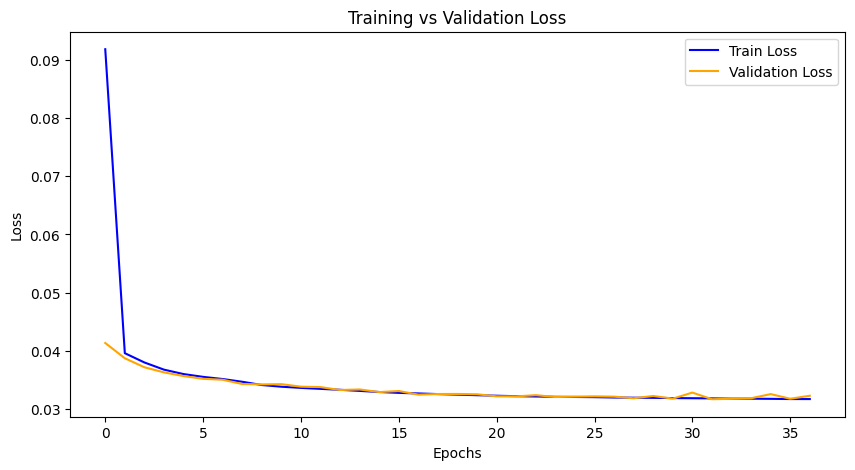

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Step 7 Determine Anomaly Threshold using Testing Data

In [18]:
#  Determine Anomaly Threshold using Training Data
model.eval()
test_recon_errors = []

with torch.no_grad():
    for data in test_loader:
        data = data[0].to(device)
        reconstructed = model(data)
        loss = torch.mean((reconstructed - data) ** 2, dim=0)  # MSE per sample
        test_recon_errors.append(loss.cpu().numpy())

test_errors =np.mean(test_recon_errors,axis=0)

In [19]:
test_errors

array([1.65885761e-02, 1.90479886e-02, 3.33872326e-02, 4.73324656e-02,
       8.84740520e-03, 7.33198831e-03, 3.56146619e-02, 5.29723950e-02,
       3.38017382e-02, 3.61005291e-02, 2.51932591e-02, 2.49897335e-02,
       1.82165913e-02, 1.75982360e-02, 1.85251590e-02, 2.39423048e-02,
       2.51492355e-02, 2.58297194e-02, 1.60756391e-02, 3.68559398e-02,
       1.55944517e-02, 1.34922778e-02, 4.16898653e-02, 3.59055437e-02,
       3.88178043e-02, 5.13610989e-02, 2.83204317e-02, 7.98283666e-02,
       8.75132531e-02, 4.67239544e-02, 1.18920624e-01, 3.70256677e-02,
       2.20631547e-02, 1.73101109e-02, 1.97061803e-02, 1.73096415e-02,
       5.12552401e-09, 2.20667068e-02], dtype=float32)

In [20]:
mean_test_error=np.mean(test_errors)

In [22]:
# Print comparison
print(f"Average Training Loss: {avg_train_loss:.6f}")
print(f"Average Validation Loss: {avg_val_loss:.6f}")
print(f"Mean Test Error: {mean_test_error:.6f}")

# Difference check
if np.isclose(avg_val_loss, mean_test_error, atol=1e-3):
    print("Validation loss and test error are close.")
else:
    print("There is a noticeable difference between validation loss and test error.")

Average Training Loss: 0.031653
Average Validation Loss: 0.032224
Mean Test Error: 0.032028
Validation loss and test error are close.


# Step 8 Inference on Pred Data

#### Batch wise inference on Pred Data  

In [23]:
model.eval()
pred_error = []
pred_loader = DataLoader(TensorDataset(pred_tensor), batch_size=180, shuffle=False, num_workers=4, pin_memory=True)


with torch.no_grad():
    for data in pred_loader:
        data = data[0].to(device)
        reconstructed = model(data)
        loss = torch.mean((reconstructed - data) ** 2, dim=0)  # MSE per sample
        pred_error.append(loss.cpu().numpy())

In [24]:
anomaly_list= []
data_dict={}
stats=[]
i=1
for row in pred_error:
    temp_dict={}
    # Element-wise division
    div_result = row/test_errors  
    temp_dict['div_result']=div_result
    # Generate 0/1 list based on threshold 5
    binary_list = (div_result > 410).astype(int)
    temp_dict['binary_list']=binary_list

    # print(binary_list)
    # Check anomaly condition (if more than 20% are 1s)
    anomaly_flag = bool(np.sum(binary_list) > (0.1 * len(binary_list)))
    temp_dict['anomaly_flag']=int(np.sum(binary_list))
    anomaly_list.append(anomaly_flag)

    data_dict['Batch_No_{}'.format(i)]=temp_dict
    i=i+1
    

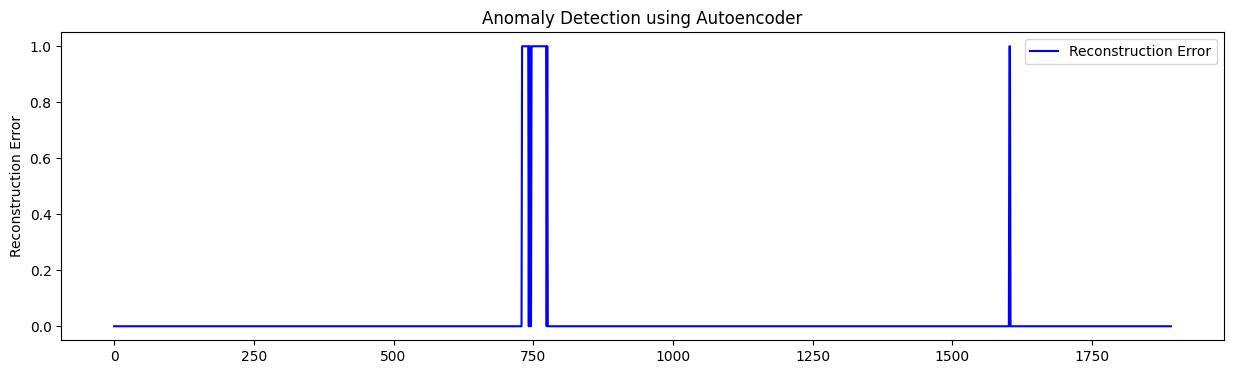

In [25]:
plt.figure(figsize=(15, 4))
plt.plot( anomaly_list, label='Reconstruction Error', color='blue')
plt.ylabel('Reconstruction Error')
plt.title('Anomaly Detection using Autoencoder')
plt.legend()
plt.show()

In [ ]:

elbow_method={}
for j in range(10,800,10): # 500 and step 10 and 5 
    anomaly_list= []
    data_dict={}
    stats=[]
    i=1
    for row in pred_error:
        temp_dict={}
        # Element-wise division
        div_result = row/test_errors  
        temp_dict['div_result']=div_result
        # Generate 0/1 list based on threshold 5
        binary_list = (div_result > j).astype(int)
        temp_dict['binary_list']=binary_list

        # print(binary_list)
        # Check anomaly condition (if more than 20% are 1s)
        anomaly_flag = bool(np.sum(binary_list) > (0.1 * len(binary_list)))
        temp_dict['anomaly_flag']=int(np.sum(binary_list))
        anomaly_list.append(anomaly_flag)

        data_dict['Batch_No_{}'.format(i)]=temp_dict
        i=i+1

    percent = [int(k) for k in anomaly_list]
    percentage_of_ones = (sum(percent) / len(percent)) * 100
    print(f"{j}: {percentage_of_ones:.2f}%")
    elbow_method[j]=percentage_of_ones

10: 99.84%
20: 93.87%
30: 80.39%
40: 65.75%
50: 57.40%
60: 48.36%
70: 38.00%
80: 30.34%
90: 26.59%
100: 22.67%
110: 20.88%
120: 18.66%
130: 16.38%
140: 14.90%
150: 13.27%
160: 12.53%
170: 11.47%
180: 10.20%
190: 8.83%
200: 8.14%
210: 7.24%
220: 6.82%
230: 6.29%
240: 6.03%
250: 5.71%
260: 5.34%
270: 4.70%
280: 4.44%
290: 4.33%
300: 4.07%
310: 3.86%
320: 3.38%
330: 3.22%
340: 3.22%
350: 2.75%
360: 2.75%
370: 2.70%
380: 2.64%
390: 2.64%
400: 2.64%
410: 2.59%
420: 2.59%
430: 2.59%
440: 2.59%
450: 2.59%
460: 2.59%
470: 2.59%
480: 2.59%
490: 2.59%
500: 2.59%
510: 2.59%
520: 2.59%
530: 2.59%
540: 2.59%
550: 2.59%
560: 2.59%
570: 2.59%
580: 2.59%
590: 2.59%
600: 2.59%
610: 2.59%
620: 2.59%
630: 2.59%
640: 2.59%
650: 2.59%
660: 2.59%
670: 2.59%
680: 2.59%
690: 2.59%
700: 2.59%
710: 2.59%
720: 2.59%
730: 2.59%
740: 2.59%
750: 2.59%
760: 2.59%
770: 2.59%
780: 2.59%
790: 2.59%


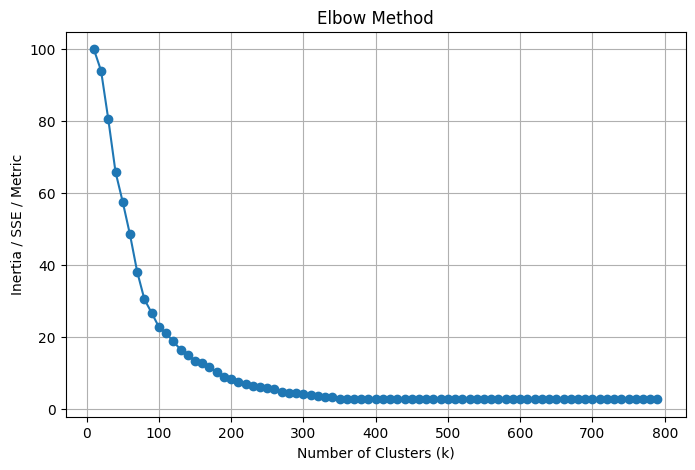

In [77]:
data = elbow_method
keys = sorted(data.keys())
values = [data[k] for k in keys]

# Plot elbow graph
plt.figure(figsize=(8, 5))
plt.plot(keys, values, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia / SSE / Metric')
plt.title('Elbow Method')
# plt.xticks(keys)
plt.grid(True)
plt.show()


In [74]:
# Parameters
stable_window = 5
delta = 0.5  # Change threshold in percentage

# Prepare data
keys = sorted(elbow_method.keys())
values = [elbow_method[k] for k in keys]

# Loop to find the first point where changes stay small for `stable_window` steps
for i in range(len(values) - stable_window):
    window = values[i:i + stable_window]
    max_change = max(window) - min(window)
    if max_change < delta:
        stable_threshold = keys[i]
        print(f"Stable threshold found at: {stable_threshold} with max change {max_change:.2f}%")
        break
else:
    print("No stable threshold found with the current criteria.")

Stable threshold found at: 350 with max change 0.11%


Stable threshold point: 380


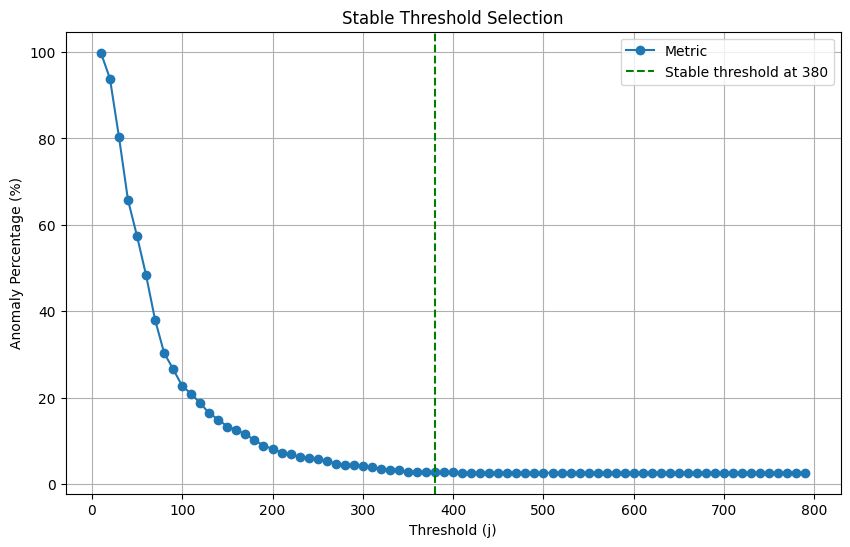

In [85]:
import numpy as np
import matplotlib.pyplot as plt

def find_stable_threshold(keys, values, stability_window=3, max_change_percent=1.0):
    """
    Find the threshold where values stabilize (change minimally) for a given window size.
    
    Parameters:
    -----------
    keys : list
        The threshold values (x-axis)
    values : list
        The corresponding percentages (y-axis)
    stability_window : int
        Number of consecutive values that should be stable (default: 5)
    max_change_percent : float
        Maximum allowed percentage change within the window (default: 1.0%)
        
    Returns:
    --------
    int : The threshold value where stability begins
    """
    if len(keys) != len(values) or len(keys) < stability_window:
        raise ValueError("Invalid input data or window size too large")
    
    for i in range(len(keys) - stability_window + 1):
        window_values = values[i:i+stability_window]
        
        # Calculate maximum percentage change within the window
        # Using max value in window to normalize
        max_val = max(window_values)
        if max_val == 0:  # Prevent division by zero
            max_val = 0.01
            
        max_diff = max(window_values) - min(window_values)
        percent_change = (max_diff / max_val) * 100
        
        if percent_change <= max_change_percent:
            return keys[i]  # Return the first key in stable window
    
    # If no stable region found
    return keys[-1]  # Return the last threshold as default

# Example usage
keys = sorted(elbow_method.keys())
values = [elbow_method[k] for k in keys]

def plot_with_stable_threshold(keys, values, stable_point):
    """
    Plot the data with the stable threshold point highlighted
    """
    plt.figure(figsize=(10, 6))
    plt.plot(keys, values, marker='o', linestyle='-', label='Metric')
    plt.axvline(x=stable_point, color='g', linestyle='--', 
                label=f'Stable threshold at {stable_point}')
    plt.xlabel('Threshold (j)')
    plt.ylabel('Anomaly Percentage (%)')
    plt.title('Stable Threshold Selection')
    plt.grid(True)
    plt.legend()
    plt.show()

# Example execution:
stable_threshold = find_stable_threshold(keys, values)
print(f"Stable threshold point: {stable_threshold}")
plot_with_stable_threshold(keys, values, stable_threshold)

Optimal threshold (elbow point): 160


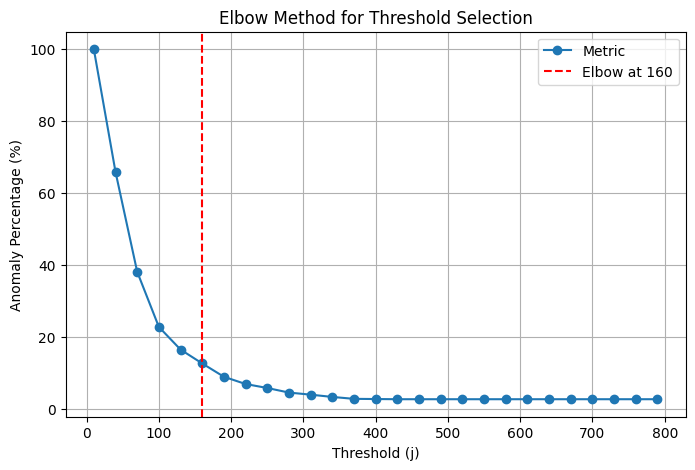

In [ ]:
from kneed import KneeLocator

keys = sorted(elbow_method.keys())
values = [elbow_method[k] for k in keys]

# Detect elbow
knee = KneeLocator(keys, values, curve="convex", direction="decreasing")
elbow_point = knee.knee
print(f"Optimal threshold (elbow point): {elbow_point}")

# Plot with elbow point
plt.figure(figsize=(8, 5))
plt.plot(keys, values, marker='o', linestyle='-', label='Metric')
plt.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow at {elbow_point}')
plt.xlabel('Threshold (j)')
plt.ylabel('Anomaly Percentage (%)')
plt.title('Elbow Method for Threshold Selection')
plt.grid(True)
plt.legend()
plt.show()


In [39]:
data = [int(i) for i in anomaly_list]
percentage_of_ones = (sum(data) / len(data)) * 100
print(f"Percentage of 1s: {percentage_of_ones:.2f}%")


Percentage of 1s: 2.75%


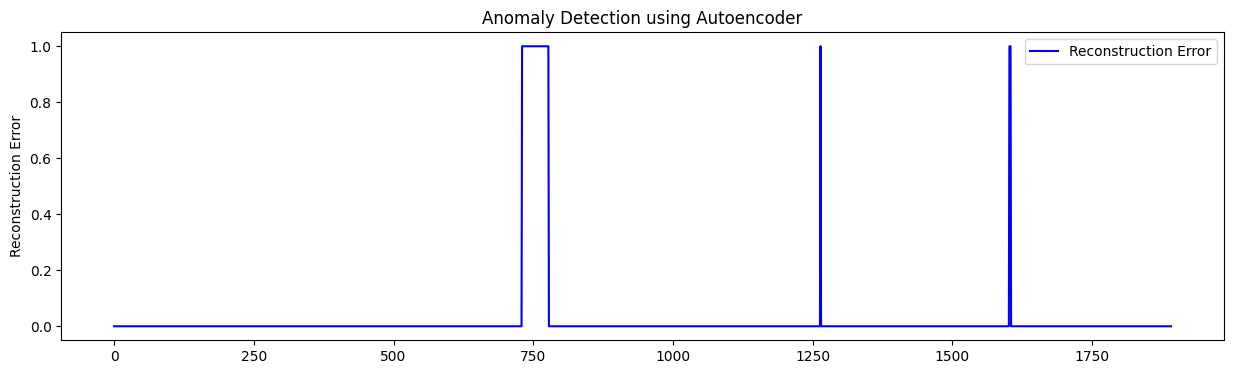

In [35]:
plt.figure(figsize=(15, 4))
plt.plot( anomaly_list, label='Reconstruction Error', color='blue')
plt.ylabel('Reconstruction Error')
plt.title('Anomaly Detection using Autoencoder')
plt.legend()
plt.show()

In [66]:
no='750'

In [67]:
pred_data = pd.read_csv('clean_data/Grey_Boy_pred_data.csv')

In [68]:
pred_data=pred_data.iloc[:,1:]

In [69]:

# Get indices where value is 1
indices = [i for i, x in enumerate(data_dict[f'Batch_No_{no}']['binary_list'].tolist()) if x == 1]
indices_zero = [i for i, x in enumerate(data_dict[f'Batch_No_{no}']['binary_list'].tolist()) if x == 0]

filtered_df = pred_data.iloc[:,indices]
filtered_df_zero = pred_data.iloc[:,indices_zero]


In [70]:
repeat_count=filtered_df.shape[0]/len(anomaly_list)

In [71]:
ver_line_pos= repeat_count*int(no)

In [72]:
def repeat_values(input_list, repeat_count=1023):
    """
    Repeat each value in the input list a specified number of times.
    
    Args:
    input_list (list): The original list to be repeated
    repeat_count (int): Number of times to repeat each value (default is 34)
    
    Returns:
    numpy.ndarray: A new array with each original value repeated
    """
    return np.repeat(input_list, repeat_count)

In [73]:
import pandas as pd
anomaly_array = repeat_values(anomaly_list,repeat_count)
pd.Series(anomaly_array).value_counts()


False    329897
True       8771
Name: count, dtype: int64

In [74]:
filtered_df.shape

(340455, 5)

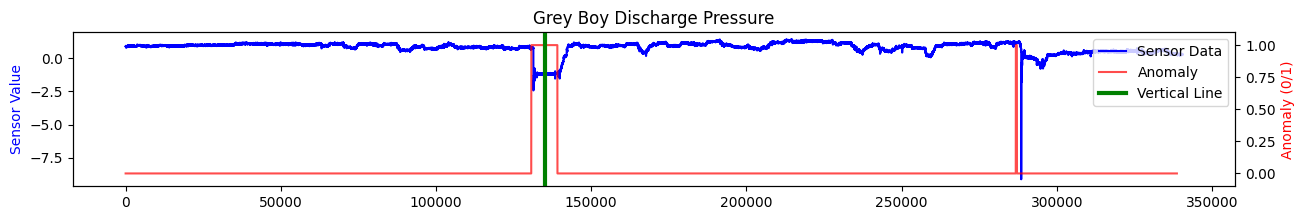

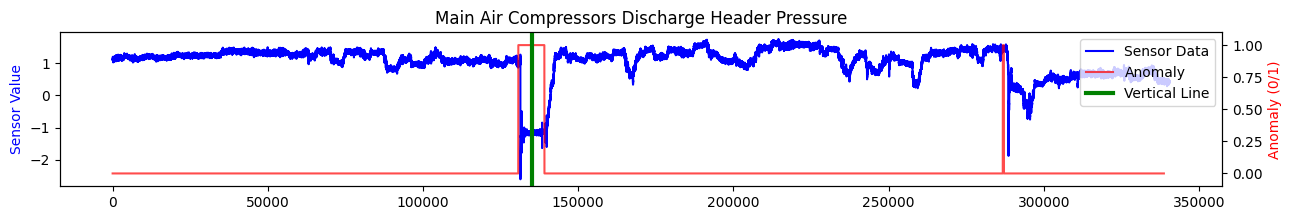

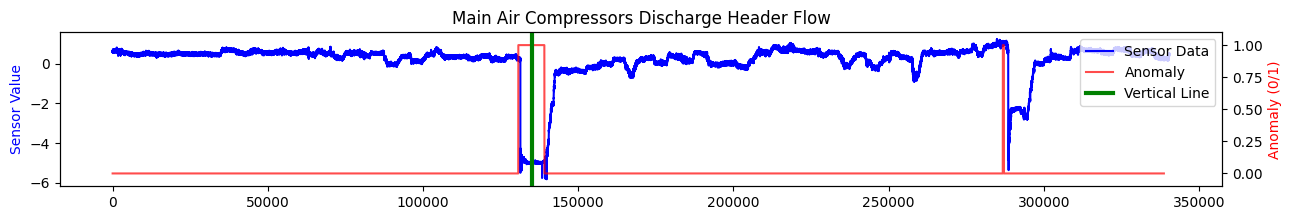

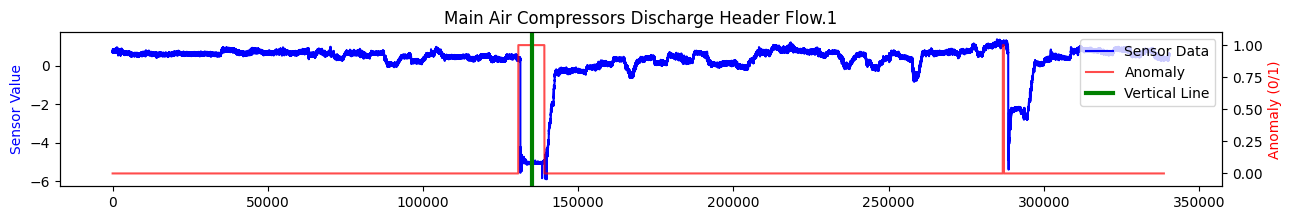

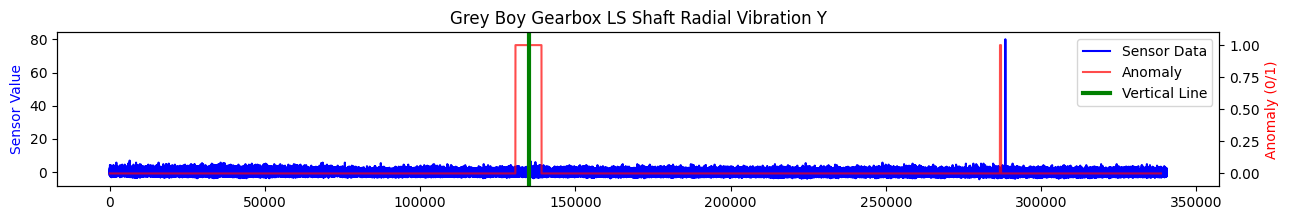

In [75]:
for i in filtered_df.columns:
    plt.figure(figsize=(15, 2))
    plt.title(f'{i}')

    # First Y-axis for sensor data
    ax1 = plt.gca()
    ax1.plot( filtered_df[i].values, color='blue', label='Sensor Data')
    ax1.set_ylabel('Sensor Value', color='blue')

    # Second Y-axis for anomaly mask
    ax2 = ax1.twinx()
    ax2.plot(anomaly_array, color='red', label='Anomaly', alpha=0.7)
    ax2.set_ylabel('Anomaly (0/1)', color='red')
    ax2.set_ylim(-0.1, 1.1)  # Optional: keep y-axis for anomaly fixed

    # Add a vertical line at a specific x-coordinate (e.g., at index 100)
    plt.axvline(x=ver_line_pos, color='green', linestyle='-', label='Vertical Line',linewidth=3)
    
    # Legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    plt.show()


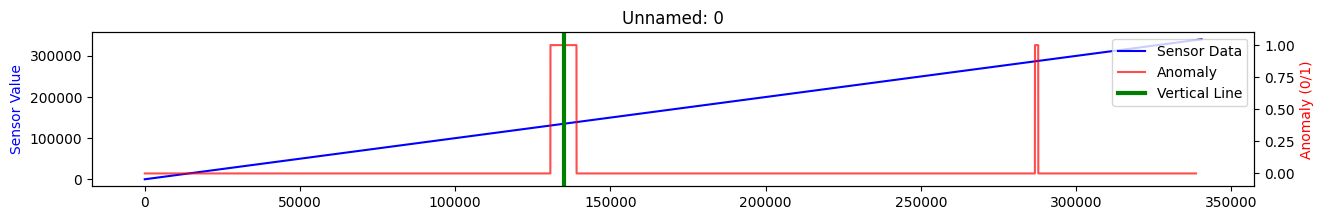

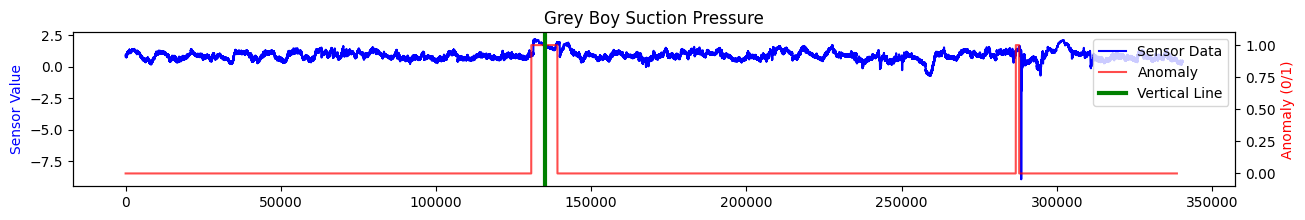

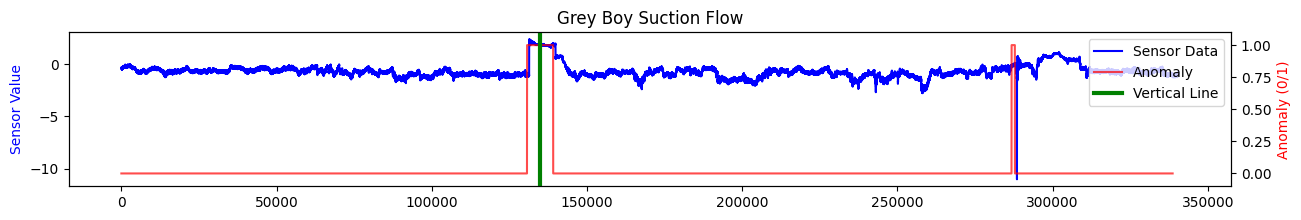

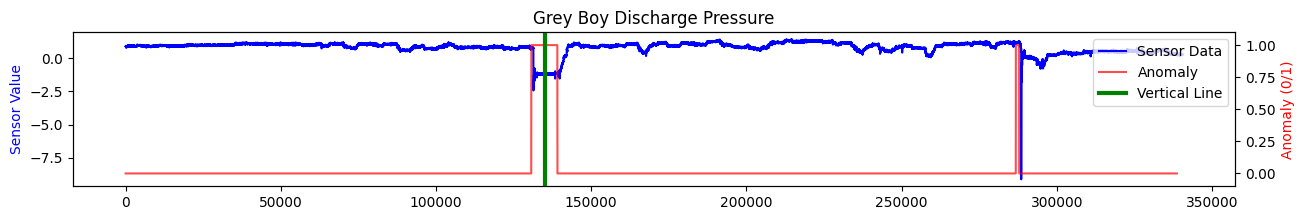

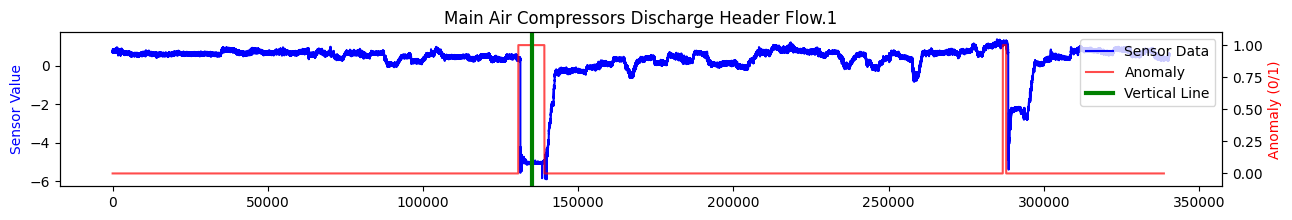

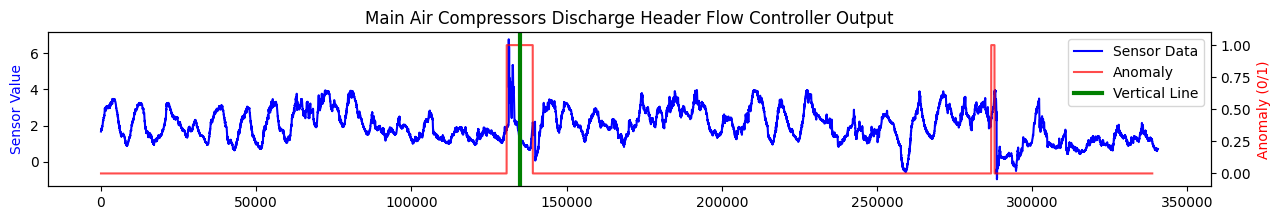

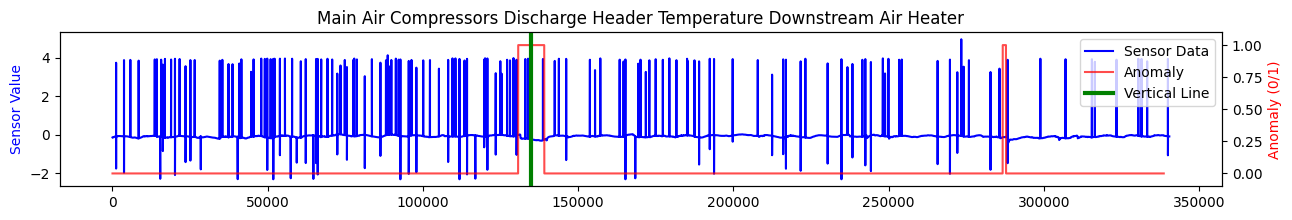

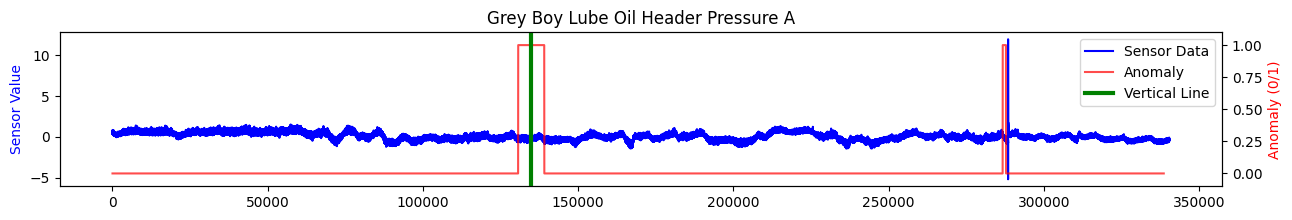

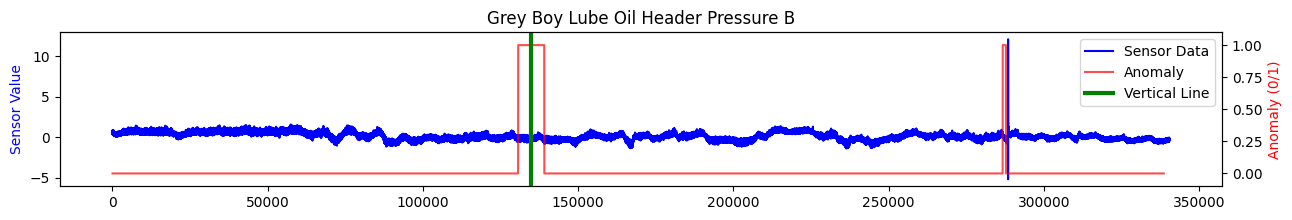

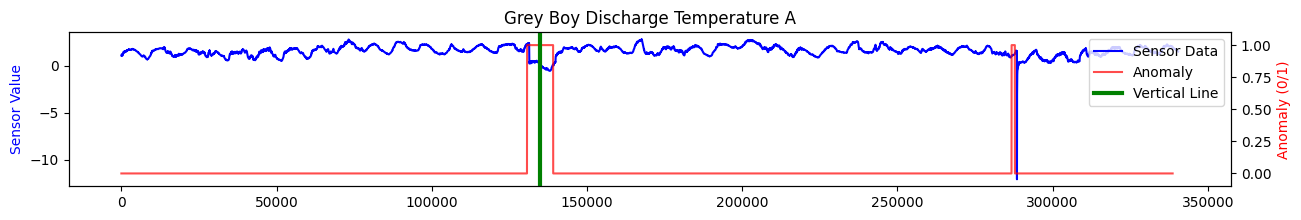

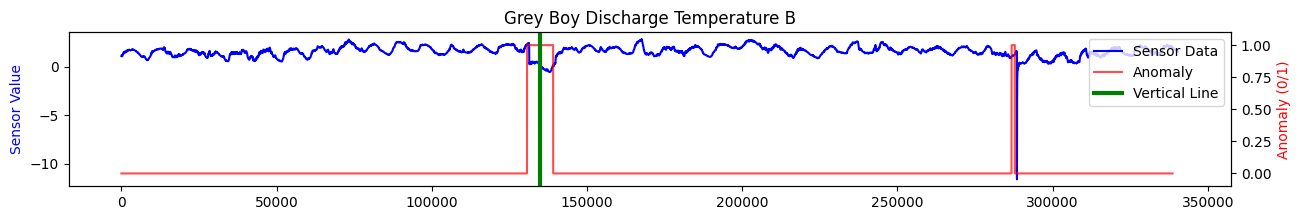

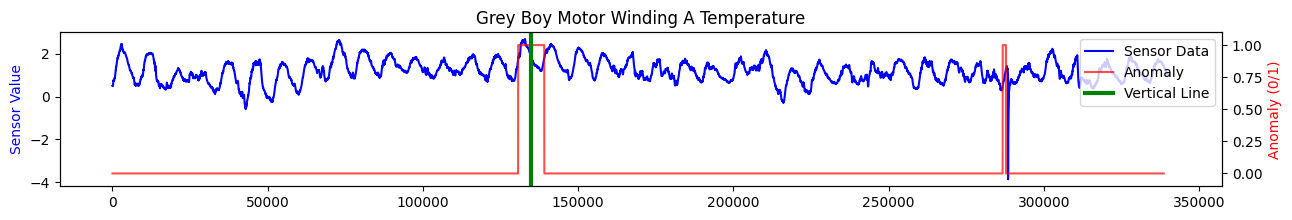

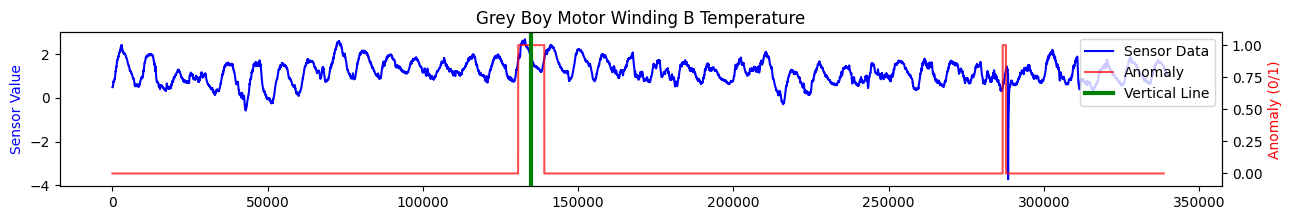

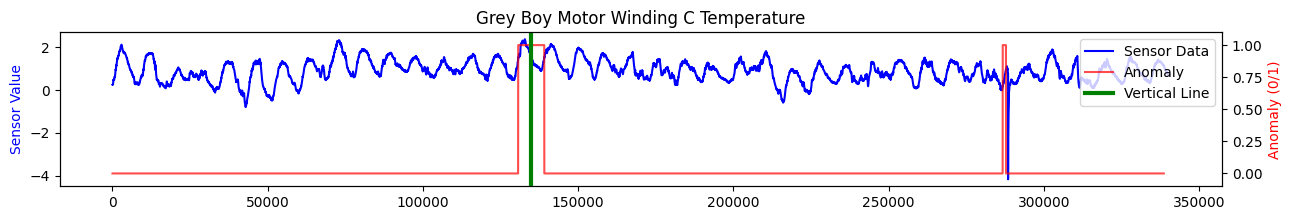

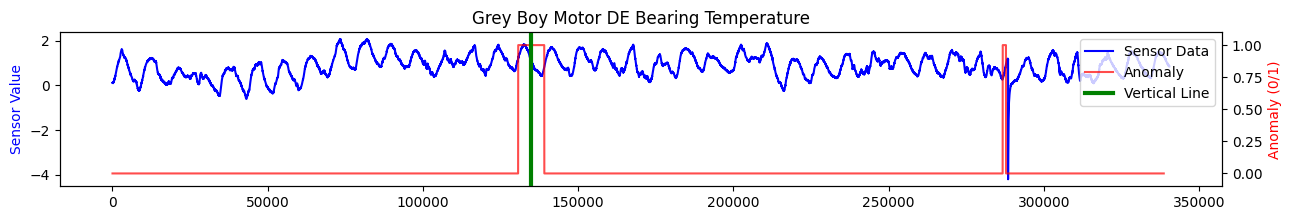

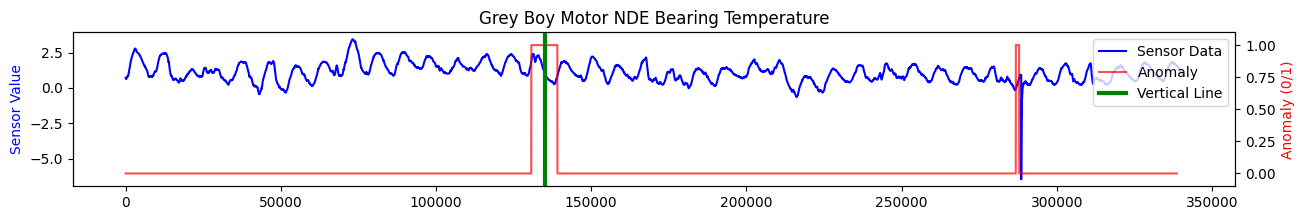

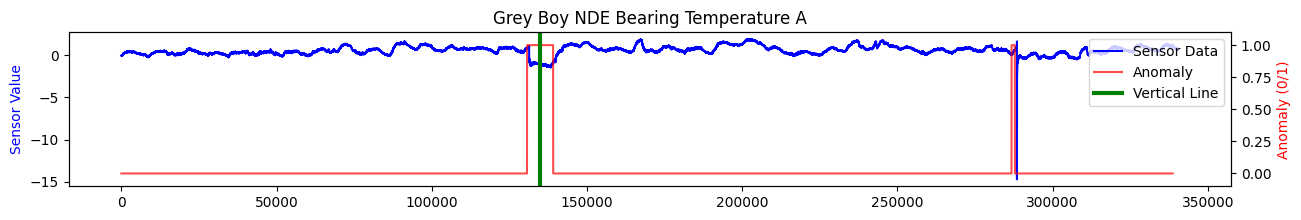

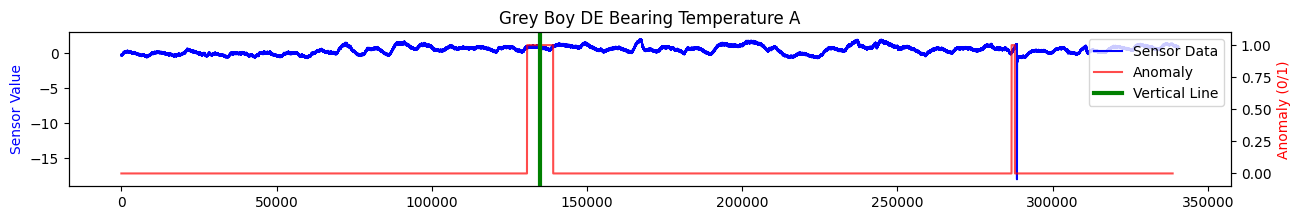

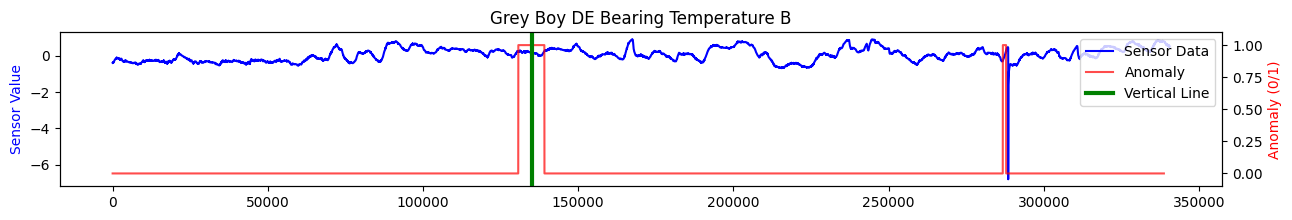

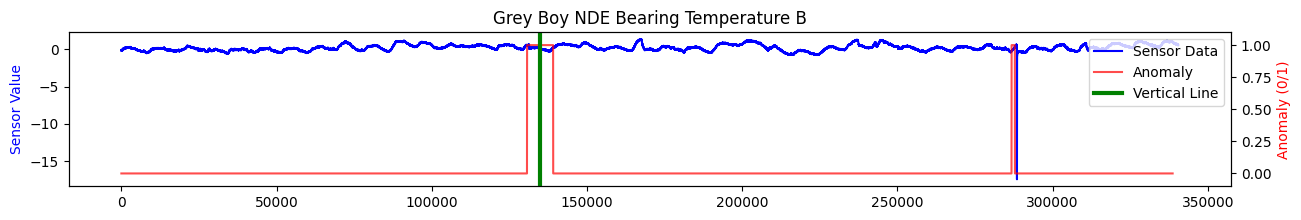

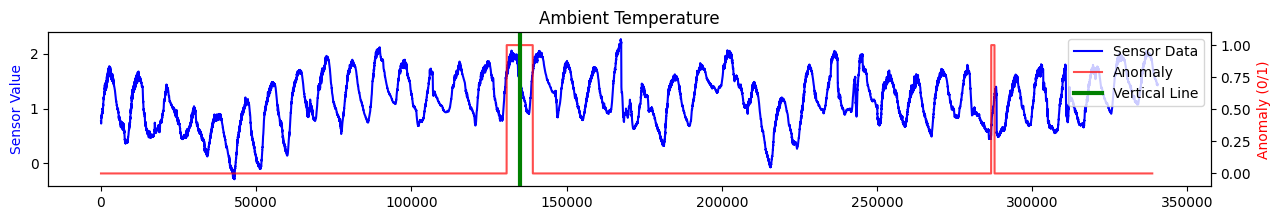

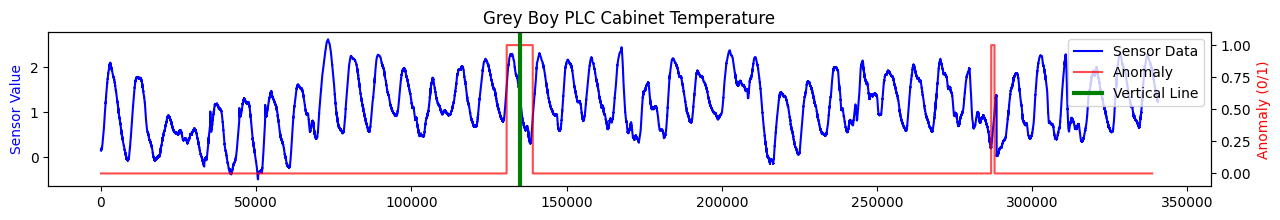

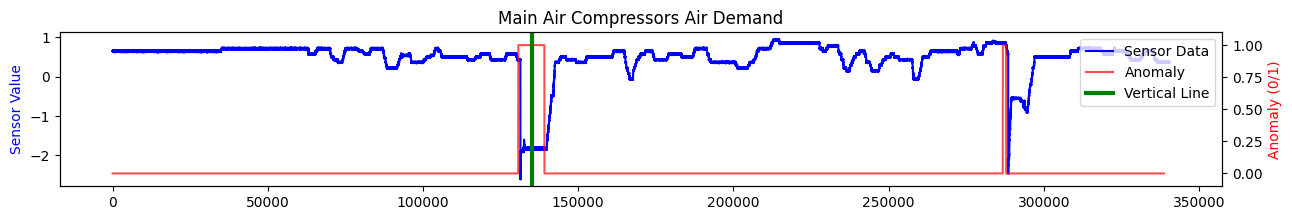

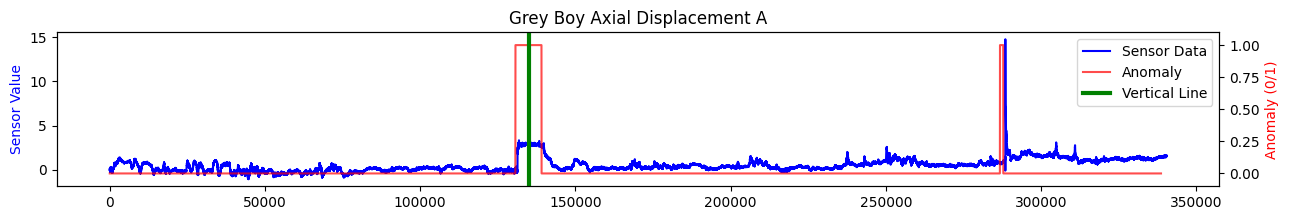

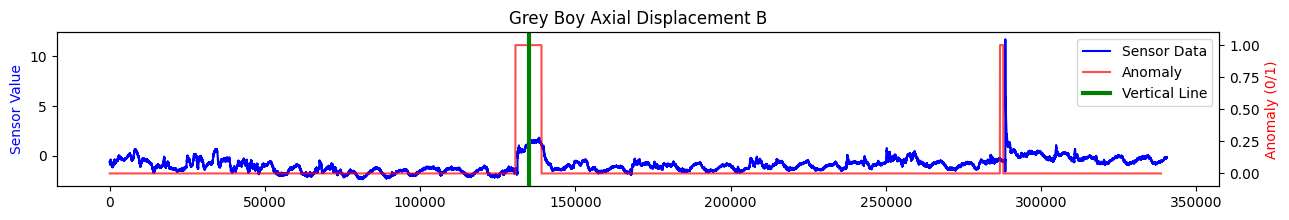

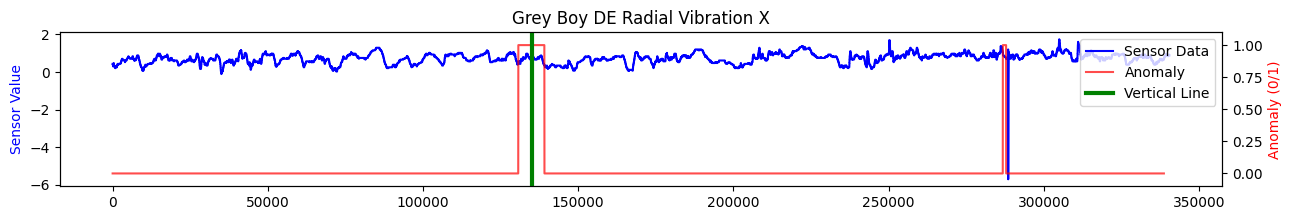

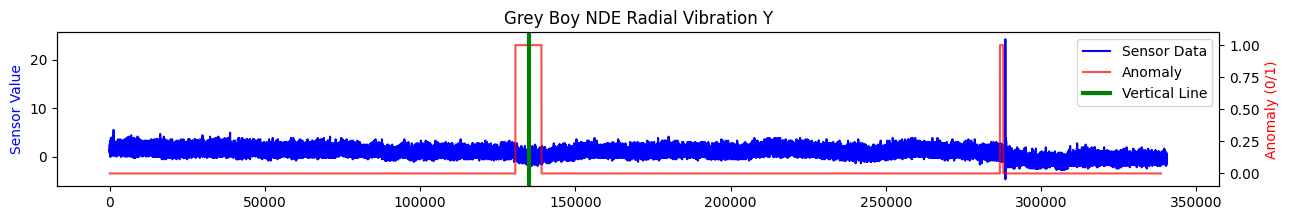

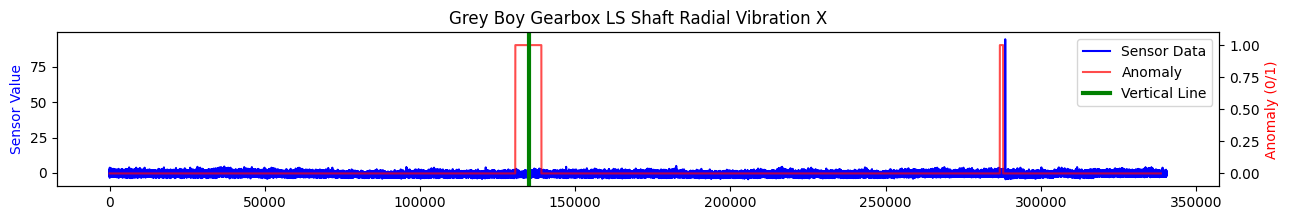

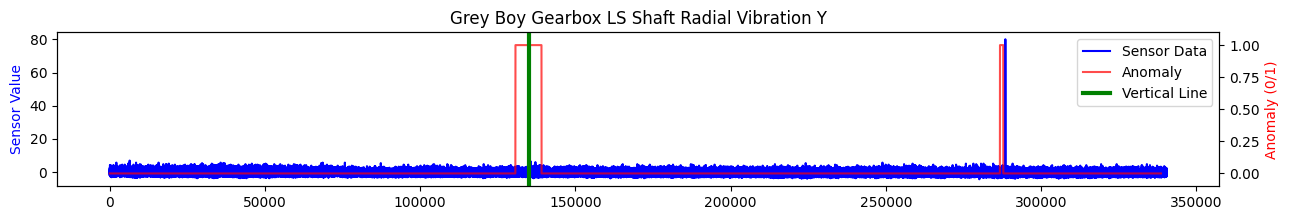

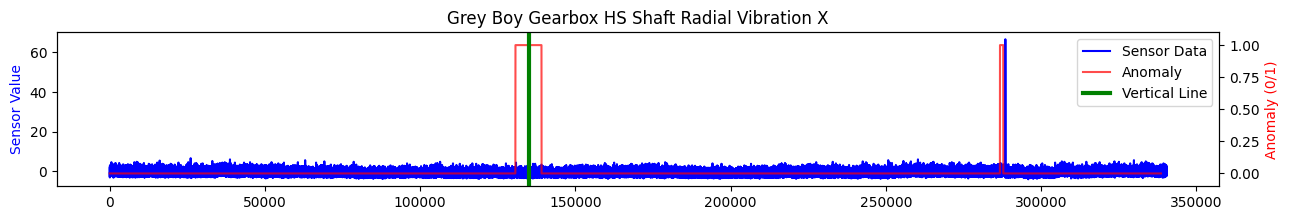

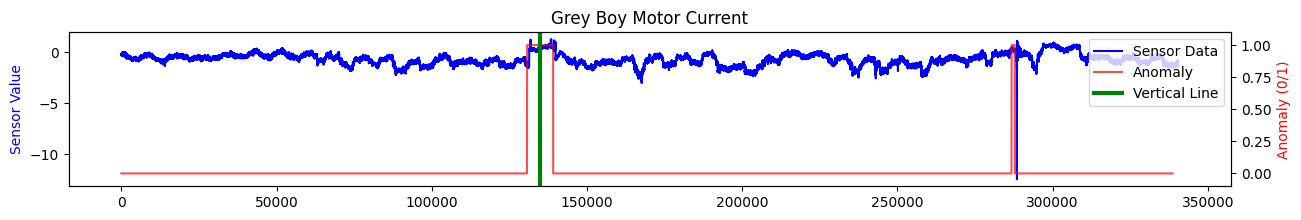

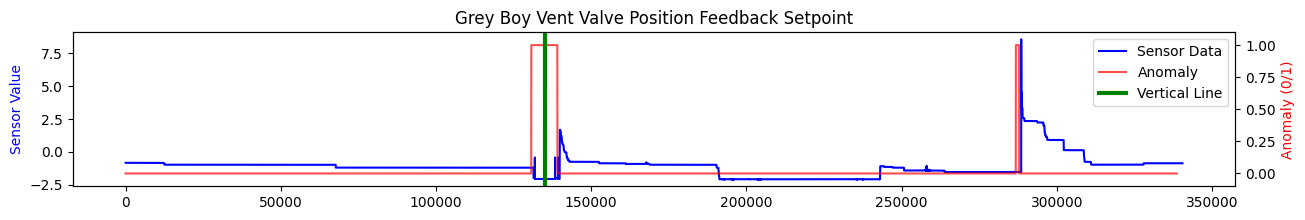

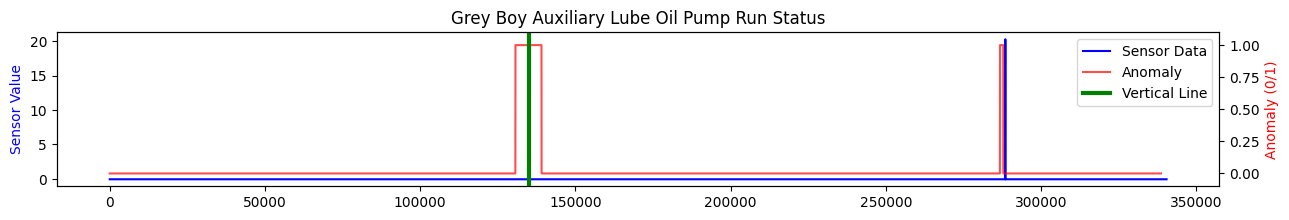

In [168]:
for i in filtered_df_zero.columns:
    plt.figure(figsize=(15, 2))
    plt.title(f'{i}')

    # First Y-axis for sensor data
    ax1 = plt.gca()
    ax1.plot( filtered_df_zero[i].values, color='blue', label='Sensor Data')
    ax1.set_ylabel('Sensor Value', color='blue')

    # Second Y-axis for anomaly mask
    ax2 = ax1.twinx()
    ax2.plot(anomaly_array, color='red', label='Anomaly', alpha=0.7)
    ax2.set_ylabel('Anomaly (0/1)', color='red')
    ax2.set_ylim(-0.1, 1.1)  # Optional: keep y-axis for anomaly fixed

    # Add a vertical line at a specific x-coordinate (e.g., at index 100)
    plt.axvline(x=ver_line_pos, color='green', linestyle='-', label='Vertical Line',linewidth=3)
    
    # Legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    plt.show()
